# Moving Average vs Naive Forecast Demo

This notebook rigorously evaluates a 3-point moving average forecasting method against a standard naive persistence forecast (which uses the previous time step's value directly) across synthetic noisy time series data.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'scikit-learn==1.6.1')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires scikit-learn>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import json
import urllib.request
import os
import matplotlib.pyplot as plt

import numpy as np
if not hasattr(np, "alltrue"): np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"): np.product = np.prod

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-230d6e-robust-temporal-smoothing-evaluating-mov/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print("Loaded data successfully. Dataset name:", data["datasets"][0]["dataset"])

Loaded data successfully. Dataset name: synthetic_noisy_timeseries


## Configuration

Define tunable parameters for generation and evaluation.

In [4]:
# Config parameters (scaled for quick demo run, set to full original values or scaled values)
N_SEEDS = 100
SERIES_LENGTH = 50
MA_WINDOW = 3

## Experiment Execution

Generate synthetic noisy time series data across multiple random seeds, and compute naive vs moving average predictions.

In [5]:
def run_experiment():
    examples = []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        t = np.arange(SERIES_LENGTH)
        series = 0.1 * t + np.sin(t * 0.2) + np.random.normal(0, 0.5, size=SERIES_LENGTH)
        
        for i in range(MA_WINDOW, len(series)):
            naive_pred = float(series[i-1])
            ma_pred = float(np.mean(series[i-MA_WINDOW:i]))
            actual = float(series[i])
            
            examples.append({
                "input": f"Series values up to index {i-1}, seed {seed}",
                "output": str(actual),
                "metadata_seed": seed,
                "metadata_timestep": i,
                "predict_naive": str(naive_pred),
                "predict_moving_average": str(ma_pred)
            })
    return examples

examples = run_experiment()
print(f"Generated {len(examples)} forecast evaluation examples across {N_SEEDS} seeds.")

Generated 4700 forecast evaluation examples across 100 seeds.


## Results & Visualization

Evaluate Mean Squared Error (MSE) for both methods and plot performance comparison.

Naive Forecast MSE: 0.5256
3-Point Moving Average MSE: 0.4350
Moving Average Win Rate: 55.1%


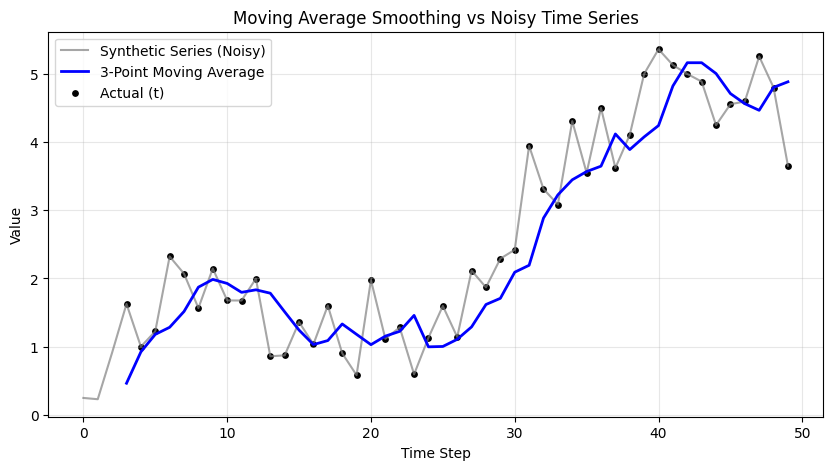

In [6]:
actuals = np.array([float(ex["output"]) for ex in examples])
naive_preds = np.array([float(ex["predict_naive"]) for ex in examples])
ma_preds = np.array([float(ex["predict_moving_average"]) for ex in examples])

mse_naive = np.mean((actuals - naive_preds) ** 2)
mse_ma = np.mean((actuals - ma_preds) ** 2)

print(f"Naive Forecast MSE: {mse_naive:.4f}")
print(f"3-Point Moving Average MSE: {mse_ma:.4f}")

# Compute trial-by-trial win rate
naive_errors = (actuals - naive_preds) ** 2
ma_errors = (actuals - ma_preds) ** 2
ma_wins = np.sum(ma_errors < naive_errors)
win_rate = ma_wins / len(actuals)
print(f"Moving Average Win Rate: {win_rate * 100:.1f}%")

# Plotting a sample time series and predictions
np.random.seed(42)
t_sample = np.arange(50)
series_sample = 0.1 * t_sample + np.sin(t_sample * 0.2) + np.random.normal(0, 0.5, size=50)
ma_sample = [np.mean(series_sample[i-3:i]) for i in range(3, len(series_sample))]

plt.figure(figsize=(10, 5))
plt.plot(t_sample, series_sample, label='Synthetic Series (Noisy)', color='gray', alpha=0.7)
plt.plot(range(3, 50), ma_sample, label='3-Point Moving Average', color='blue', linewidth=2)
plt.scatter(range(3, 50), series_sample[3:], color='black', s=15, label='Actual (t)')
plt.title('Moving Average Smoothing vs Noisy Time Series')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()